Using device: cpu
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

=== Training ResNet18 (Seed 42) ===
Epoch [1/15] - Loss: 0.4458 - Val Acc: 91.04%
Epoch [2/15] - Loss: 0.1085 - Val Acc: 92.58%
Epoch [3/15] - Loss: 0.0451 - Val Acc: 92.27%
Epoch [4/15] - Loss: 0.0179 - Val Acc: 92.74%
Epoch [5/15] - Loss: 0.0135 - Val Acc: 92.74%
Epoch [6/15] - Loss: 0.0077 - Val Acc: 93.35%
Epoch [7/15] - Loss: 0.0164 - Val Acc: 92.43%
Epoch [8/15] - Loss: 0.0286 - Val Acc: 90.88%
Epoch [9/15] - Loss: 0.0309 - Val Acc: 91.34%
Epoch [10/15] - Loss: 0.0401 - Val Acc: 91.50%
Epoch [11/15] - Loss: 0.0339 - Val Acc: 92.27%
Epoch [12/15] - Loss: 0.0222 - Val Acc: 92.12%
Epoch [13/15] - Loss: 0.0181 - Val Acc: 92.43%
Epoch [14/15] - Loss: 0.0047 - Val Acc: 92.58%
Epoch [15/15] - Loss: 0.0086 - Val Acc: 93.51%

ResNet18 (Seed 42) Test Accuracy: 93.35%
              precision    recall  f1-score   support

       daisy     0.9457    0.9606    0.9531       127
   dandelion     0.9542    0.9359   

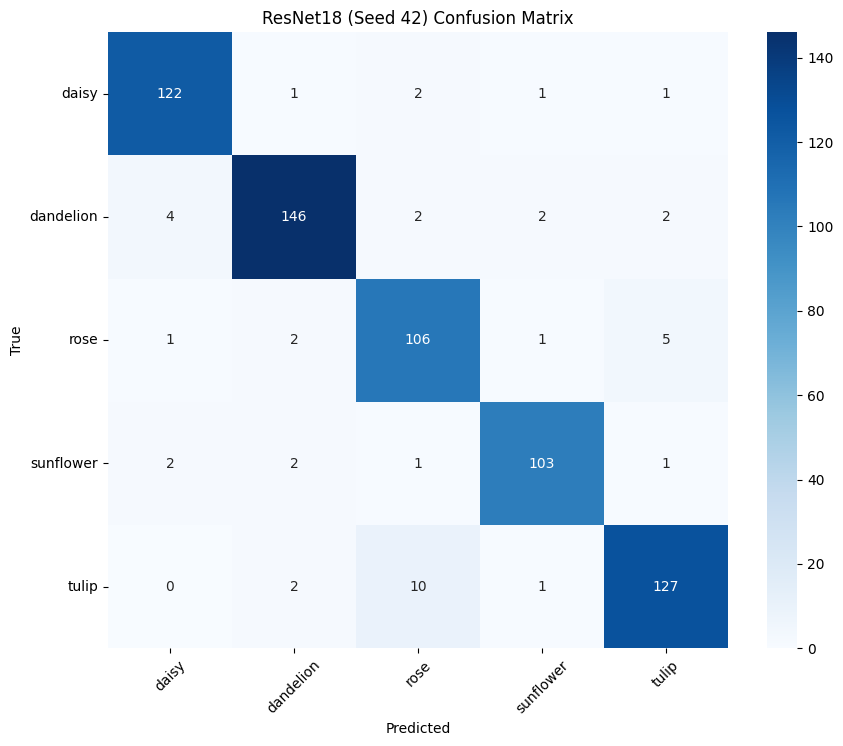


=== Training EfficientNet-B0 (Seed 42) ===
Epoch [1/15] - Loss: 0.8254 - Val Acc: 90.42%
Epoch [2/15] - Loss: 0.2687 - Val Acc: 92.27%
Epoch [3/15] - Loss: 0.1560 - Val Acc: 92.74%
Epoch [4/15] - Loss: 0.0889 - Val Acc: 92.89%
Epoch [5/15] - Loss: 0.0549 - Val Acc: 93.82%
Epoch [6/15] - Loss: 0.0519 - Val Acc: 93.66%
Epoch [7/15] - Loss: 0.0420 - Val Acc: 92.89%
Epoch [8/15] - Loss: 0.0309 - Val Acc: 93.66%
Epoch [9/15] - Loss: 0.0291 - Val Acc: 94.59%
Epoch [10/15] - Loss: 0.0258 - Val Acc: 93.97%
Epoch [11/15] - Loss: 0.0222 - Val Acc: 94.74%
Epoch [12/15] - Loss: 0.0141 - Val Acc: 94.13%
Epoch [13/15] - Loss: 0.0115 - Val Acc: 94.28%
Epoch [14/15] - Loss: 0.0156 - Val Acc: 94.59%
Epoch [15/15] - Loss: 0.0167 - Val Acc: 93.82%

EfficientNet-B0 (Seed 42) Test Accuracy: 94.13%
              precision    recall  f1-score   support

       daisy     0.9449    0.9449    0.9449       127
   dandelion     0.9800    0.9423    0.9608       156
        rose     0.8833    0.9217    0.9021     

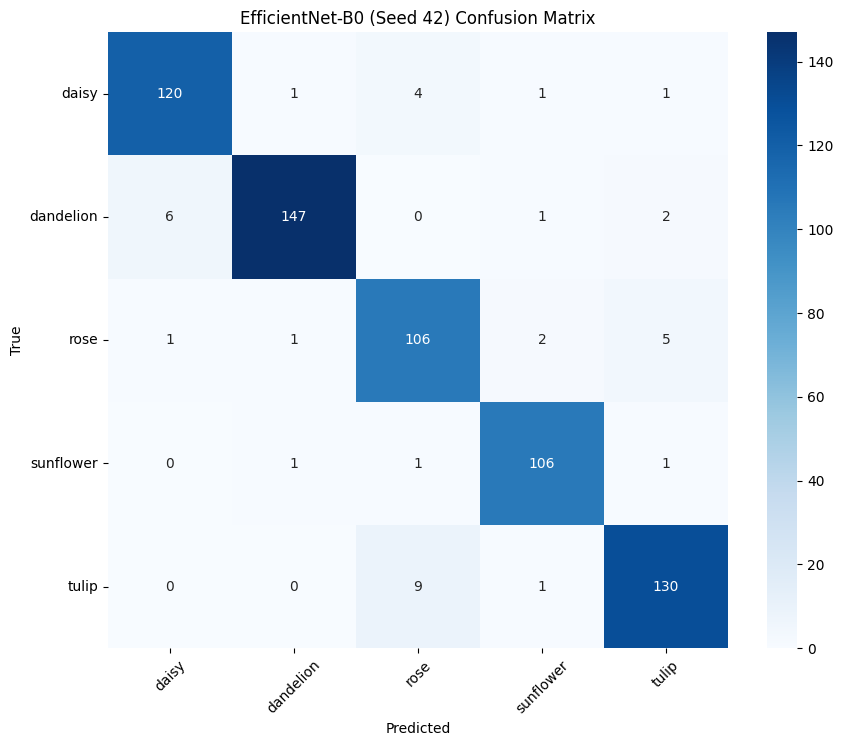


=== Training MobileNetV2 (Seed 42) ===
Epoch [1/15] - Loss: 0.9138 - Val Acc: 87.48%
Epoch [2/15] - Loss: 0.3319 - Val Acc: 90.73%
Epoch [3/15] - Loss: 0.2012 - Val Acc: 92.58%
Epoch [4/15] - Loss: 0.1178 - Val Acc: 92.89%
Epoch [5/15] - Loss: 0.0817 - Val Acc: 92.58%
Epoch [6/15] - Loss: 0.0556 - Val Acc: 93.20%
Epoch [7/15] - Loss: 0.0389 - Val Acc: 93.04%
Epoch [8/15] - Loss: 0.0315 - Val Acc: 92.43%
Epoch [9/15] - Loss: 0.0206 - Val Acc: 92.43%
Epoch [10/15] - Loss: 0.0159 - Val Acc: 92.27%
Epoch [11/15] - Loss: 0.0106 - Val Acc: 92.43%
Epoch [12/15] - Loss: 0.0101 - Val Acc: 92.43%
Epoch [13/15] - Loss: 0.0121 - Val Acc: 92.58%
Epoch [14/15] - Loss: 0.0105 - Val Acc: 92.43%
Epoch [15/15] - Loss: 0.0064 - Val Acc: 92.74%

MobileNetV2 (Seed 42) Test Accuracy: 92.12%
              precision    recall  f1-score   support

       daisy     0.9435    0.9213    0.9323       127
   dandelion     0.9416    0.9295    0.9355       156
        rose     0.8860    0.8783    0.8821       115
  

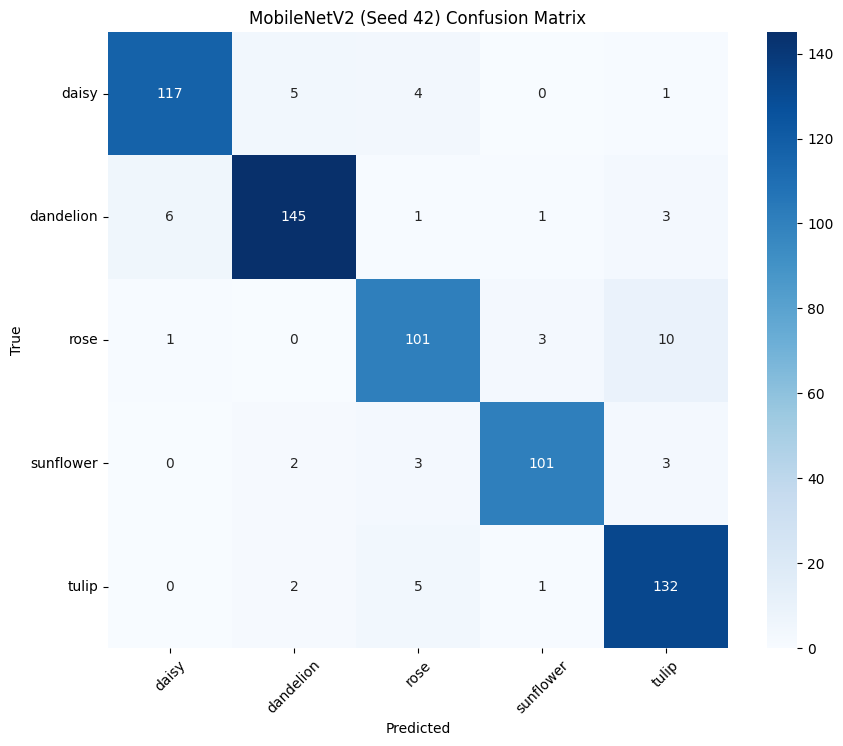


=== Training ResNet18 (Seed 123) ===


KeyboardInterrupt: 

In [ ]:
# Flower Classification with ResNet18 
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import seaborn as sns

# ==== CONFIGURATION ====
data_dir = r"D:\ml_lern\dataset"
batch_size = 32
image_size = 224  # Standard size for pretrained models
epochs = 15
learning_rate = 0.0001
model_save_path = "models/flower_resnet18.pth"
seeds = [42, 123, 456]  # For statistical significance

# ==== ENHANCED DATA TRANSFORMS ====
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

# ==== MULTI-MODEL TRAINING FUNCTION ====
def train_and_evaluate(model, train_loader, val_loader, test_loader, criterion, optimizer, epochs, model_name):
    print(f"\n=== Training {model_name} ===")
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images, val_labels = val_images.to(device), val_labels.to(device)
                val_outputs = model(val_images)
                _, val_preds = torch.max(val_outputs, 1)
                val_correct += (val_preds == val_labels).sum().item()
                val_total += val_labels.size(0)

        val_acc = 100 * val_correct / val_total
        train_losses.append(running_loss / len(train_loader))
        val_accuracies.append(val_acc)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {train_losses[-1]:.4f} - Val Acc: {val_acc:.2f}%")

    # Test Evaluation
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_images, test_labels = test_images.to(device), test_labels.to(device)
            test_outputs = model(test_images)
            _, test_preds = torch.max(test_outputs, 1)
            test_correct += (test_preds == test_labels).sum().item()
            test_total += test_labels.size(0)
            all_preds.extend(test_preds.cpu().numpy())
            all_labels.extend(test_labels.cpu().numpy())

    test_acc = 100 * test_correct / test_total
    print(f"\n{model_name} Test Accuracy: {test_acc:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()
    
    return test_acc, train_losses, val_accuracies

# ==== MAIN EXPERIMENT LOOP ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset once
full_dataset = datasets.ImageFolder(root=data_dir)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")

results = []
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Create splits with correct transforms
    train_set = datasets.ImageFolder(root=data_dir, transform=train_transform)
    test_size = int(0.15 * len(train_set))
    val_size = int(0.15 * len(train_set))
    train_size = len(train_set) - val_size - test_size
    
    train_set, val_set, test_set = random_split(
        train_set, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )
    
    # Apply test transform to val/test
    val_set.dataset.transform = test_transform
    test_set.dataset.transform = test_transform
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    # ==== MODEL COMPARISON ====
    models_dict = {
        'ResNet18': models.resnet18(weights='DEFAULT'),
        'EfficientNet-B0': models.efficientnet_b0(weights='DEFAULT'),
        'MobileNetV2': models.mobilenet_v2(weights='DEFAULT')
    }
    
    for name, model in models_dict.items():
        # Modify final layer
        if 'resnet' in name.lower():
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        else:
            if 'efficientnet' in name.lower():
                model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
            else:
                model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        
        model = model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()
        
        acc, _, _ = train_and_evaluate(
            model, train_loader, val_loader, test_loader,
            criterion, optimizer, epochs, f"{name} (Seed {seed})"
        )
        results.append((name, seed, acc))

# ==== STATISTICAL ANALYSIS ====
print("\n=== Final Results ===")
import pandas as pd
df = pd.DataFrame(results, columns=['Model', 'Seed', 'Accuracy'])
print(df.groupby('Model').agg({'Accuracy': ['mean', 'std']}))

# ==== SAVE BEST MODEL ====
best_model = models.resnet18(weights='DEFAULT')
best_model.fc = nn.Linear(best_model.fc.in_features, num_classes)
best_model.load_state_dict(torch.load(model_save_path))
best_model.to(device)
torch.save(best_model.state_dict(), "models/best_flower_model.pth")

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# === CONFIGURATION ===
data_dir = r"D:\ml_lern\dataset"
batch_size = 32
image_size = 224
epochs = 15
learning_rate = 0.0001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# === TRANSFORMS ===
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# === LOAD CLASS NAMES ===
full_dataset = datasets.ImageFolder(root=data_dir)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")

# === TRAIN/EVAL FUNCTION ===
def train_and_evaluate(model, train_loader, val_loader, test_loader, criterion, optimizer, epochs, model_name):
    print(f"\n=== Training {model_name} ===")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = 100 * val_correct / val_total
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {running_loss/len(train_loader):.4f} - Val Acc: {val_acc:.2f}%")

    # Testing
    model.eval()
    test_correct = 0
    test_total = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * test_correct / test_total
    print(f"\n{model_name} Test Accuracy: {test_acc:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# === RUN ONLY FOR SEEDS 123 and 456 ===
remaining_seeds = [123, 456]
for seed in remaining_seeds:
    print(f"\n\n##### Seed {seed} #####")
    torch.manual_seed(seed)
    np.random.seed(seed)

    train_set = datasets.ImageFolder(root=data_dir, transform=train_transform)
    test_size = int(0.15 * len(train_set))
    val_size = int(0.15 * len(train_set))
    train_size = len(train_set) - val_size - test_size

    train_set, val_set, test_set = random_split(
        train_set, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )

    val_set.dataset.transform = test_transform
    test_set.dataset.transform = test_transform

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    # MODELS
    models_dict = {
        'ResNet18': models.resnet18(weights='DEFAULT'),
        'EfficientNet-B0': models.efficientnet_b0(weights='DEFAULT'),
        'MobileNetV2': models.mobilenet_v2(weights='DEFAULT')
    }

    for name, model in models_dict.items():
        if 'resnet' in name.lower():
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        else:
            if 'efficientnet' in name.lower():
                model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
            else:
                model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

        model = model.to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.CrossEntropyLoss()

        train_and_evaluate(model, train_loader, val_loader, test_loader,
                           criterion, optimizer, epochs, f"{name} (Seed {seed})")


Using device: cpu
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


##### Seed 123 #####

=== Training ResNet18 (Seed 123) ===
Epoch [1/15] - Loss: 0.4565 - Val Acc: 91.04%
Epoch [2/15] - Loss: 0.1023 - Val Acc: 92.89%
Epoch [3/15] - Loss: 0.0374 - Val Acc: 93.20%
Epoch [4/15] - Loss: 0.0313 - Val Acc: 93.66%
Epoch [5/15] - Loss: 0.0196 - Val Acc: 92.74%
Epoch [6/15] - Loss: 0.0179 - Val Acc: 91.50%
Epoch [7/15] - Loss: 0.0230 - Val Acc: 93.04%
Epoch [8/15] - Loss: 0.0209 - Val Acc: 93.66%
Epoch [9/15] - Loss: 0.0135 - Val Acc: 93.35%
Epoch [10/15] - Loss: 0.0096 - Val Acc: 94.44%
Epoch [11/15] - Loss: 0.0076 - Val Acc: 93.35%
Epoch [12/15] - Loss: 0.0054 - Val Acc: 93.82%


KeyboardInterrupt: 